In [1]:
# imports 
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
import pickle

import lightning as L
seed = 42
L.seed_everything(seed, workers=True)

import xarray as xr
import xskillscore as xs
import warnings
import os


from src.models.unet_module import UnetLitModule
from src.models.gan_module import UnetGANLitModule
from src.models.ae_module import AutoencoderKL, EncoderLRES
from src.models.ldm_module import LatentDiffusion

from src.models.components.unet import DownscalingUnet
from src.models.components.ae import SimpleConvDecoder, SimpleConvEncoder
from src.models.components.ldm.denoiser import UNetModel, DDIMSampler
from src.models.components.ldm.conditioner import AFNOConditionerNetCascade
from src.data.downscaling_datamodule import DownscalingDataModule
from src.data.components.downscaling_dataset import DownscalingDataset

from utils.inference_utils import get_model_output
from utils.plotting_utils import get_target_grid, show_metrics, from_torchtensor_to_xarray

/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/lightning/fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


[rank: 0] Global seed set to 42


Pysteps configuration file found at: /home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/pysteps/pystepsrc



In [2]:
# Setting paths to data

# results_file_path = '../outputs/results_pde.pkl'
results_file_path = '../outputs/Our_results_trained_models_2mT.pkl'
pretrained_metrics_file_path = '../pretrained_models/outputs/metrics_trained_models.pkl'
output_path = '../outputs/'

In [3]:
#Loading in dataframes

results_df = pd.read_pickle(results_file_path)
pretrained_metrics_df = pd.read_pickle(pretrained_metrics_file_path)

In [4]:
#printing head and tails

print(results_df.columns)
print(results_df.shape)
print(results_df.head())
print(results_df.tail())

print_metrics = True
if print_metrics:
    print(f'\n\n =======================Pretrained Metrics below======================= \n\n')

    print(pretrained_metrics_df.columns)
    print(pretrained_metrics_df.shape)
    print(pretrained_metrics_df.head())
    print(pretrained_metrics_df.tail())
    print(pretrained_metrics_df['metric'].unique().tolist())

Index(['input_var', 'target_var', 'model', 'variable', 'spat_distr', 'min',
       'max', 'time_step'],
      dtype='object')
(1485, 8)


  input_var target_var model variable  \
0       all        2mT  ERA5      2mT   
1       all        2mT  ERA5      2mT   
2       all        2mT  ERA5      2mT   
3       all        2mT  ERA5      2mT   
4       all        2mT  ERA5      2mT   

                                          spat_distr         min         max  \
0  [[tensor(282.5619), tensor(282.5619), tensor(2...  272.312256  290.437225   
1  [[tensor(273.5626), tensor(273.5626), tensor(2...  258.944519  289.312317   
2  [[tensor(287.2497), tensor(287.2497), tensor(2...  281.060699  300.498718   
3  [[tensor(289.4377), tensor(289.4377), tensor(2...  275.939758  301.378571   
4  [[tensor(277.4988), tensor(277.4988), tensor(2...  269.379364  290.562653   

            time_step  
0 2014-04-24 02:00:00  
1 2014-12-28 03:00:00  
2 2019-09-02 02:00:00  
3 2006-05-14 10:00:00  
4 2016-05-02 04:00:00  


     input_var target_var        model variable  \
1480       all        2mT  LMM_PDE_res      2mT   
1481       all        2mT  LMM_PDE_res      2mT   
1482       all        2mT  LMM_PDE_res      2mT   
1483       all        2mT  LMM_PDE_res      2mT   
1484       all        2mT  LMM_PDE_res      2mT   

                                             spat_distr         min  \
1480  [[tensor(284.5319), tensor(284.1742), tensor(2...  270.861881   
1481  [[tensor(279.1283), tensor(278.8480), tensor(2...  264.727159   
1482  [[tensor(289.7451), tensor(288.9073), tensor(2...  276.799087   
1483  [[tensor(274.9709), tensor(274.6860), tensor(2...  271.640270   
1484  [[tensor(281.2368), tensor(281.5231), tensor(2...  268.212016   

             max           time_step  
1480  296.420864 2004-10-16 18:00:00  
1481  296.452972 2001-11-09 12:00:00  
1482  298.140737 2002-09-09 23:00:00  
1483  296.928170 2013-10-31 07:00:00  
1484  287.135575 2002-01-05 17:00:00  


 =======================Pretra

In [5]:
# split results_df into separate dataframes, one per model

model_types = results_df['model'].unique().tolist()

results = {}
for model_type in model_types:
    model_df = results_df[results_df['model'] == model_type]
    model_df = model_df.reset_index(drop=True)
    results[model_type] = model_df

print(results.keys())

dict_keys(['ERA5', 'COSMO-CLM', 'Quadratic Interp.', 'Linear Interp.', 'UNET', 'GAN', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res'])


In [6]:
# Computing metrics for each model
metric_models = [model for model in model_types if model not in ['ERA5', 'COSMO-CLM']]
metrics_list = []

target_grid_high_res = get_target_grid('high')

for model_i in metric_models:
    cosmo_df = results['COSMO-CLM']
    for _, model_i_row in results[model_i].iterrows():
        cosm_sel = cosmo_df[
            (cosmo_df['time_step'] == model_i_row['time_step'])
            & (cosmo_df['input_var'] == model_i_row['input_var'])
            & (cosmo_df['target_var'] == model_i_row['target_var'])
            & (cosmo_df['variable'] == model_i_row['variable'])
        ]
        if len(cosm_sel) != 1:
            raise ValueError(
                f"Expected one COSMO-CLM row for time_step={model_i_row['time_step']!r} "
                f"model={model_i!r} var={model_i_row['variable']!r}; got {len(cosm_sel)}"
            )
        cosmo_row = cosm_sel.iloc[0]

        cosmo_spat_distr = cosmo_row['spat_distr']
        model_i_spat_distr = model_i_row['spat_distr']

        cosmo_xr = from_torchtensor_to_xarray(cosmo_spat_distr, target_grid_high_res, coords_name='y_x')
        model_i_xr = from_torchtensor_to_xarray(model_i_spat_distr, target_grid_high_res, coords_name='y_x')

        # Computing the 4 metrics listed in Appendix B
        model_i_rmse = xs.rmse(model_i_xr, cosmo_xr).item() # RMSE
        model_i_me = xs.me(model_i_xr, cosmo_xr).item() # BIAS (mean error)
        model_i_r2 = xs.r2(model_i_xr, cosmo_xr).item() # coefficient of determination
        model_i_pearson = xs.pearson_r(model_i_xr, cosmo_xr).item() # Pearson correlation

        # Appending the metrics to the list
        model_i_metrics = {
            'RMSE': model_i_rmse,
            'R2': model_i_r2,
            'BIAS': model_i_me,
            'PCC': model_i_pearson
        }

        for model_i_metric in model_i_metrics:
            metrics_list.append({
                'model': model_i,
                'target_var': model_i_row['target_var'],
                'var': model_i_row['variable'],
                'metric': model_i_metric,
                'value': model_i_metrics[model_i_metric],
            })

metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df.reset_index(drop=True)

print(metrics_df)
metrics_df.to_pickle(output_path + './Our_inference_metrics' + '.pkl')  

                  model target_var  var metric     value
0     Quadratic Interp.        2mT  2mT   RMSE  1.901043
1     Quadratic Interp.        2mT  2mT     R2  0.775449
2     Quadratic Interp.        2mT  2mT   BIAS -0.696168
3     Quadratic Interp.        2mT  2mT    PCC  0.897757
4     Quadratic Interp.        2mT  2mT   RMSE  1.952612
...                 ...        ...  ...    ...       ...
4615        LMM_PDE_res        2mT  2mT    PCC  0.992107
4616        LMM_PDE_res        2mT  2mT   RMSE  0.676629
4617        LMM_PDE_res        2mT  2mT     R2  0.981190
4618        LMM_PDE_res        2mT  2mT   BIAS -0.116602
4619        LMM_PDE_res        2mT  2mT    PCC  0.990851

[4620 rows x 5 columns]


[Done] Super-grid PDE flux ratio metrics computed and appended to metrics_df.


/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,

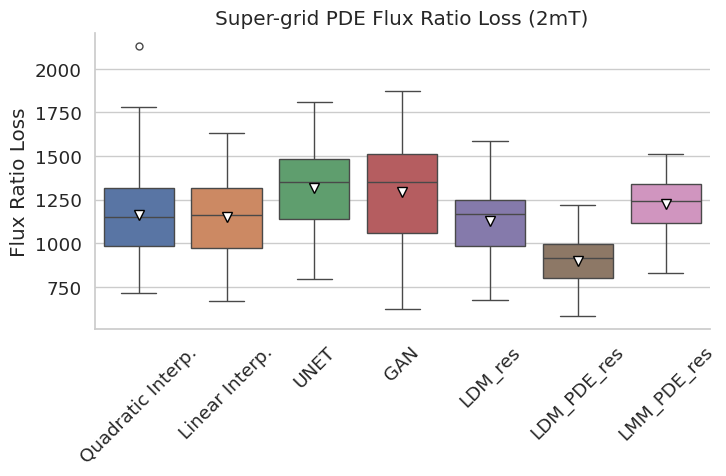

               model target_var  var metric     value
0  Quadratic Interp.        2mT  2mT   RMSE  1.901043
1  Quadratic Interp.        2mT  2mT     R2  0.775449
2  Quadratic Interp.        2mT  2mT   BIAS -0.696168
3  Quadratic Interp.        2mT  2mT    PCC  0.897757
4  Quadratic Interp.        2mT  2mT   RMSE  1.952612
5  Quadratic Interp.        2mT  2mT     R2  0.928309
6  Quadratic Interp.        2mT  2mT   BIAS  0.651627
7  Quadratic Interp.        2mT  2mT    PCC  0.968924
8  Quadratic Interp.        2mT  2mT   RMSE  2.872576
9  Quadratic Interp.        2mT  2mT     R2  0.619683


In [7]:
# Compute and Plot Super-Grid PDE Flux Ratio Metric 

import torch
import numpy as np


# GPU-accelerated supercell flux ratio code 

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_gradients_torch(T, dx=1.0, dy=1.0, eps=1e-6):
    H, W = T.shape
    dTdx = torch.zeros_like(T)
    dTdy = torch.zeros_like(T)
    # Interior
    if W > 2:
        dTdx[:, 1:-1] = (T[:, 2:] - T[:, :-2]) / (2.0 * dx)
    if H > 2:
        dTdy[1:-1, :] = (T[2:, :] - T[:-2, :]) / (2.0 * dy)
    # Boundaries
    if W > 1:
        dTdx[:, 0] = (T[:, 1] - T[:, 0]) / dx
        dTdx[:, -1] = (T[:, -1] - T[:, -2]) / dx
    if H > 1:
        dTdy[0, :] = (T[1, :] - T[0, :]) / dy
        dTdy[-1, :] = (T[-1, :] - T[-2, :]) / dy
    return dTdx, dTdy

def compute_block_effective_flux_ratio_torch(
    T_block, dTdx_block, dTdy_block, dx=1.0, dy=1.0, eps=1e-6
):
    device = T_block.device
    H, W = T_block.shape
    adv_vals, diff_vals = [], []
    
    def process_edge(i_idx, j_idx, nx, ny):
        grad_x = dTdx_block[i_idx, j_idx]
        grad_y = dTdy_block[i_idx, j_idx]
        Tvals  = T_block[i_idx, j_idx]
        grad_norm = torch.sqrt(grad_x**2 + grad_y**2) + eps
        g_hat_x = grad_x / grad_norm
        g_hat_y = grad_y / grad_norm
        dot = g_hat_x * nx + g_hat_y * ny
        adv_ = Tvals * dot
        diff_ = torch.sqrt(grad_x**2 + grad_y**2)
        return adv_, diff_
    
    # Top Edge
    if H > 0:
        i_top = torch.zeros(W, dtype=torch.long, device=device)
        j_top = torch.arange(W, device=device)
        adv, dif = process_edge(i_top, j_top, nx=0.0, ny=-1.0)
        adv_vals.append(adv)
        diff_vals.append(dif)
    # Bottom Edge
    if H > 1:
        i_bot = torch.full((W,), H - 1, dtype=torch.long, device=device)
        j_bot = torch.arange(W, device=device)
        adv, dif = process_edge(i_bot, j_bot, nx=0.0, ny=1.0)
        adv_vals.append(adv)
        diff_vals.append(dif)
    # Left Edge
    if W > 0 and H > 2:
        i_left = torch.arange(1, H - 1, device=device)
        j_left = torch.zeros(H - 2, dtype=torch.long, device=device)
        adv, dif = process_edge(i_left, j_left, nx=-1.0, ny=0.0)
        adv_vals.append(adv)
        diff_vals.append(dif)
    # Right Edge
    if W > 1 and H > 2:
        i_right = torch.arange(1, H - 1, device=device)
        j_right = torch.full((H - 2,), W - 1, dtype=torch.long, device=device)
        adv, dif = process_edge(i_right, j_right, nx=1.0, ny=0.0)
        adv_vals.append(adv)
        diff_vals.append(dif)
    
    if len(adv_vals) == 0:
        return 0.0

    adv_all = torch.cat(adv_vals)
    diff_all = torch.cat(diff_vals)
    return (torch.mean(adv_all) / (torch.mean(diff_all) + eps)).item()

def compute_supercell_flux_ratio_field(
    T, supercell_size=16, dx=1.0, dy=1.0, eps=1e-6
):
    device = get_device()
    if not isinstance(T, torch.Tensor):
        T_torch = torch.from_numpy(T).float().to(device)
    else:
        T_torch = T.float().to(device)
    H, W = T_torch.shape
    dTdx, dTdy = compute_gradients_torch(T_torch, dx=dx, dy=dy, eps=eps)
    num_cells_vert = H // supercell_size
    num_cells_horiz = W // supercell_size
    R_eff_field = torch.zeros((num_cells_vert, num_cells_horiz), device=device)
    for i in range(num_cells_vert):
        for j in range(num_cells_horiz):
            r0, r1 = i*supercell_size, (i+1)*supercell_size
            c0, c1 = j*supercell_size, (j+1)*supercell_size
            T_block    = T_torch[r0:r1, c0:c1]
            dTdx_block = dTdx[r0:r1, c0:c1]
            dTdy_block = dTdy[r0:r1, c0:c1]
            R_eff = compute_block_effective_flux_ratio_torch(T_block, dTdx_block, dTdy_block, dx=dx, dy=dy, eps=eps)
            R_eff_field[i, j] = R_eff
    return R_eff_field.cpu().numpy()

def compute_flux_ratio_loss_supercell(ref_field, pred_field, supercell_size=16, dx=1.0, dy=1.0, eps=1e-6):
    R_ref = compute_supercell_flux_ratio_field(ref_field, supercell_size, dx, dy, eps)
    R_pred = compute_supercell_flux_ratio_field(pred_field, supercell_size, dx, dy, eps)
    # If shapes differ, take overlap
    min_h = min(R_ref.shape[0], R_pred.shape[0])
    min_w = min(R_ref.shape[1], R_pred.shape[1])
    R_ref = R_ref[:min_h, :min_w]
    R_pred = R_pred[:min_h, :min_w]
    # PDE-style flux ratio difference = mean absolute difference
    return np.mean(np.abs(R_pred - R_ref))


# Compute super-grid flux ratio metric for each model/time/2mT
fluxratio_metrics_list = []
for model_i in metric_models:
    # Only do flux ratio for 2mT
    model_rows_2mt = results[model_i][results[model_i]['variable'] == '2mT']
    for idx, row in model_rows_2mt.iterrows():
        ts = row['time_step']
        # Matching ERA5 row => reference coarse
        era5_row = results['ERA5'][(results['ERA5']['time_step'] == ts) &
                                   (results['ERA5']['variable'] == '2mT')]
        if era5_row.empty:
            continue
        # Numpy or array data
        T_c = era5_row.iloc[0]['spat_distr'].numpy() if hasattr(era5_row.iloc[0]['spat_distr'],'numpy') \
             else era5_row.iloc[0]['spat_distr']
        T_f = row['spat_distr'].numpy() if hasattr(row['spat_distr'],'numpy') else row['spat_distr']
        
        flux_loss = compute_flux_ratio_loss_supercell(T_c, T_f, supercell_size=16, dx=1.0, dy=1.0, eps=1e-6)
        fluxratio_metrics_list.append({
            'model': model_i,
            'target_var': row['target_var'],
            'var': row['variable'],
            'metric': 'FluxRatio',
            'value': flux_loss,
        })

if fluxratio_metrics_list:
    fluxratio_df = pd.DataFrame(fluxratio_metrics_list)
    metrics_df = pd.concat([metrics_df, fluxratio_df], ignore_index=True)

print("[Done] Super-grid PDE flux ratio metrics computed and appended to metrics_df.")
metrics_df.to_pickle(output_path + './Our_inference_metrics_with_PDE.pkl')


# Plot the distribution of "FluxRatio" metric, similar to other metrics

import seaborn as sns
sns.set_theme(font_scale=1.2, style="whitegrid")

fluxratio_plot_df = metrics_df[metrics_df['metric'] == 'FluxRatio'].copy()
if len(fluxratio_plot_df) == 0:
    print("No 'FluxRatio' metrics found in metrics_df. Skipping super-grid PDE flux ratio plot.")
else:
    g = sns.catplot(
        data=fluxratio_plot_df, kind='box',
        x='model', y='value', hue='model',
        height=5, aspect=1.5, legend=False,
        showmeans=True,
        meanprops={'marker': 'v', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 7}
    )
    for ax in g.axes.flatten():
        for label in ax.get_xticklabels():
            label.set_rotation(45)
        ax.set_xlabel("")
        ax.set_title("Super-grid PDE Flux Ratio Loss (2mT)")
        ax.set_ylabel("Flux Ratio Loss")
    
    # Adjust legend, remove duplicates
    if g._legend is not None:
        g._legend.remove()
    plt.tight_layout()
    plt.show()
# Append the flux ratio metrics to the existing metrics DataFrame
if fluxratio_metrics_list:
    fluxratio_df = pd.DataFrame(fluxratio_metrics_list)
    metrics_df = pd.concat([metrics_df, fluxratio_df], ignore_index=True)

# Save the updated metrics DataFrame to file
metrics_df.to_pickle(output_path + './Our_inference_metrics_with_PDE.pkl')

# (Optional) Print the head of the updated dataframe to verify the new entries
print(metrics_df.head(10))



/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/chuongtnd/git-repo/Physically-conditioned-l

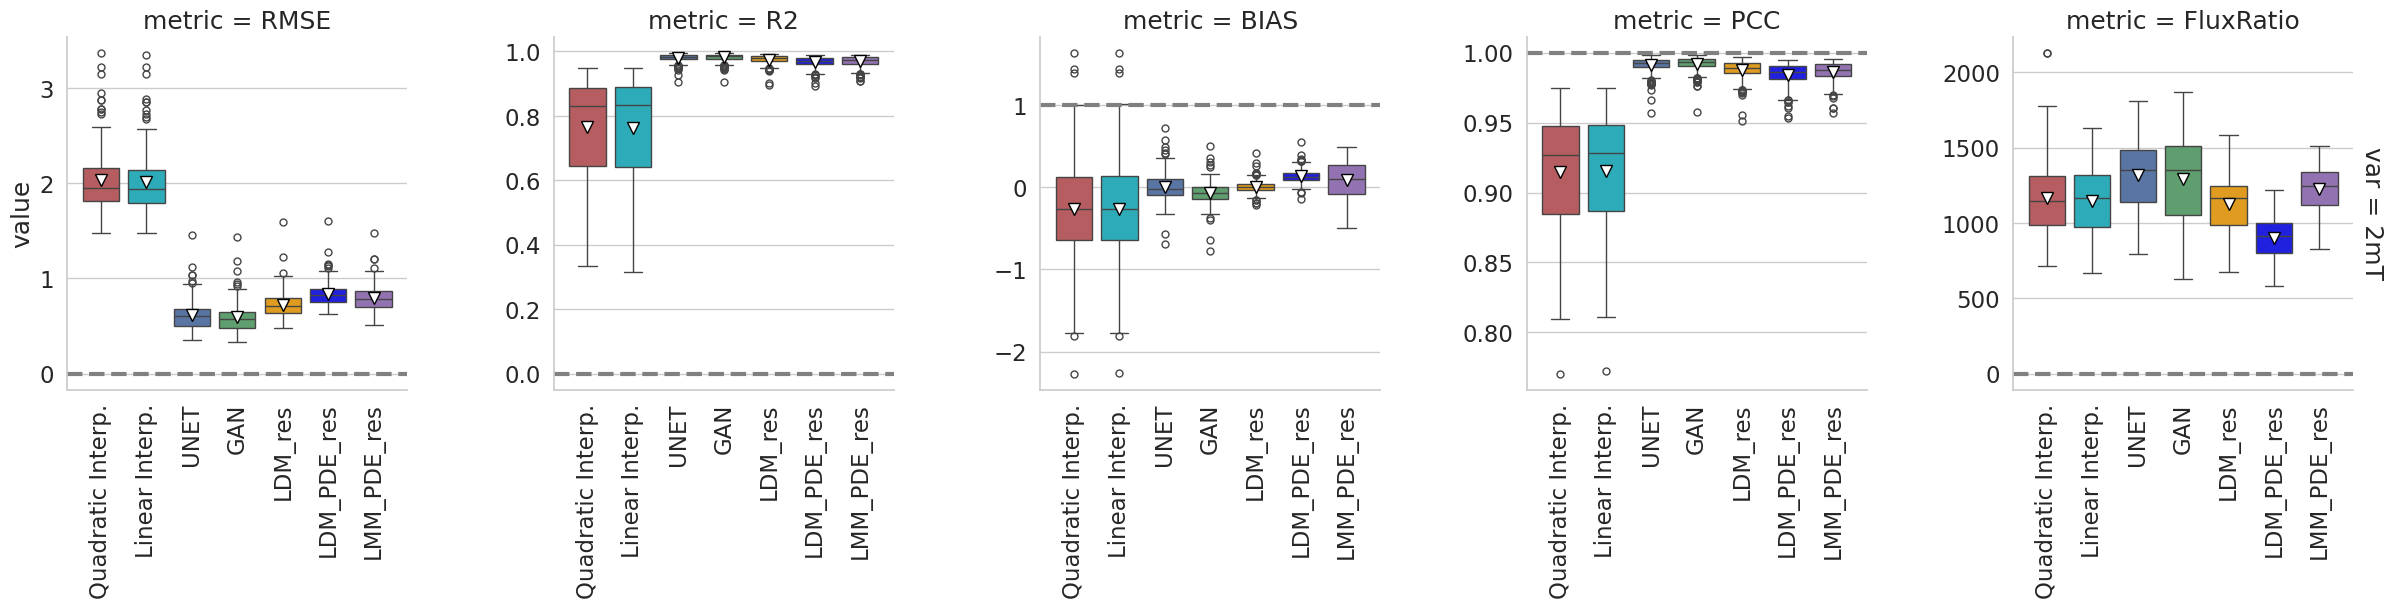

In [8]:
# Plotting metrics
def show_mT_metrics(metrics, output_dir, save_to_file):
    """
    Slightly modified version of show_metrics from utils.plotting_utils
    """

    # Set up plotting resources
    box_palette = {
        'Quadratic Interp.': 'r',
        'Linear Interp.': '#17becf',
        'UNET': 'b',
        'GAN': 'g',
        'VAE_res': 'pink',
        'LDM_res': 'orange',
        'LDM_PDE_res': 'blue',
        'LMM_PDE_res': '#9467bd'
    }
    y_ref = [0,0,1,1,0,0,1,1]
    # Plot boxplots
    sns.set_theme(font_scale=1.5, style="whitegrid")
    g = sns.catplot(data=metrics, kind='box', x="model", y="value", col="metric", row='var', hue='model', native_scale=True, sharey=False, margin_titles=True, palette=box_palette, showmeans=True,
                    meanprops={'marker':'v','markerfacecolor':'w','markeredgecolor':'black','markersize':'8'})
    for i,ax in enumerate(g.axes.flat):
        for label in ax.get_xticklabels():
            label.set_rotation(90)
        ax.axline((0, y_ref[i]), slope=0, linestyle='--', color='gray', linewidth=3)
        ax.set(xlabel=None)
    if g._legend is not None:
        g._legend.remove()

    if save_to_file:
        # Save to file
        g.savefig(output_dir + 'Fig_metrics.jpg')

show_mT_metrics(metrics_df, output_path, False)

In [9]:
# --- Cell 9 (code) ---
import numpy as np


# Helper functions

def _radial_spectral_slope(field: np.ndarray):
    """Return log-log slope of radially averaged 2-D power spectrum."""
    field = np.squeeze(field) - field.mean()
    H, W   = field.shape
    P      = np.abs(np.fft.fftshift(np.fft.fft2(field)))**2

    # radial distances (pixel units) from spectrum centre
    y, x   = np.indices((H, W))
    r      = np.sqrt((y - H/2)**2 + (x - W/2)**2).astype(int)

    max_r  = min(H, W)//2
    radial_mean = np.bincount(r.ravel(), P.ravel()) / np.maximum(1, np.bincount(r.ravel()))
    radial_mean = radial_mean[1:max_r]      # skip DC component (r=0)
    radii       = np.arange(1, len(radial_mean)+1)

    # keep only bins with positive power
    mask = radial_mean > 0
    if mask.sum() < 3:              # spectrum too short for a fit
        return np.nan
    log_k = np.log10(radii[mask])
    log_P = np.log10(radial_mean[mask])
    slope, _ = np.polyfit(log_k, log_P, 1)
    return slope                    

def _spectral_slope_error(ref, pred):
    s_ref  = _radial_spectral_slope(ref)
    s_pred = _radial_spectral_slope(pred)
    return np.abs(s_pred - s_ref)


# Loop through models/timesteps and compute the spectral slope difference

physical_metrics = []
for model_name in metric_models:                      # defined earlier
    rows_2mt = results[model_name][results[model_name]['variable'] == '2mT']
    for _, row in rows_2mt.iterrows():
        ts = row['time_step']
        ref_row = results['COSMO-CLM'][
            (results['COSMO-CLM']['time_step'] == ts) &
            (results['COSMO-CLM']['variable']   == '2mT')
        ]
        if ref_row.empty:
            continue

        ref_field  = ref_row.iloc[0]['spat_distr']
        pred_field = row['spat_distr']
        ref_np     = ref_field.numpy()  if hasattr(ref_field,  'numpy') else ref_field
        pred_np    = pred_field.numpy() if hasattr(pred_field, 'numpy') else pred_field

        # spectral slope difference
        slope_err = _spectral_slope_error(ref_np, pred_np)

        physical_metrics.append({
            'model':      model_name,
            'target_var': row['target_var'],
            'var':        row['variable'],
            'metric':     'SpectralSlopeDiff',
            'value':      slope_err
        })

# Append and save
physical_df = pd.DataFrame(physical_metrics)
metrics_df  = pd.concat([metrics_df, physical_df], ignore_index=True)
metrics_df.to_pickle(output_path + './Our_inference_metrics_with_PDE_Phys.pkl')

print("✔ Added SpectralSlopeDiff (lower = better).")


✔ Added SpectralSlopeDiff (lower = better).


/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/chuongtnd/git-repo/Physically-conditioned-l

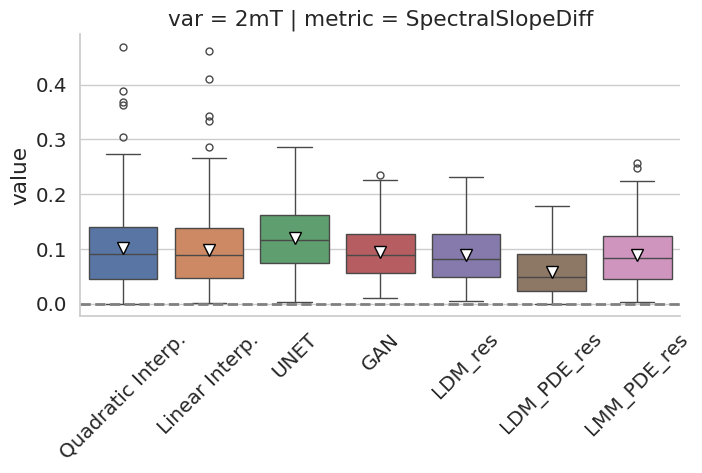

In [10]:

import seaborn as sns
import matplotlib.pyplot as plt

# only keep the slope‐difference metric
plot_metrics = ['SpectralSlopeDiff']
plot_df = metrics_df[metrics_df['metric'].isin(plot_metrics)].copy()

sns.set_theme(style="whitegrid", font_scale=1.3)
g = sns.catplot(
    data      = plot_df,
    kind      = 'box',
    x         = 'model',
    y         = 'value',
    hue       = 'model',
    col       = 'metric',
    row       = 'var',
    sharey    = False,
    height    = 5,
    aspect    = 1.3,
    showmeans = True,
    meanprops = {'marker':'v','markerfacecolor':'white',
                 'markeredgecolor':'black','markersize':8}
)

for ax in g.axes.flatten():
    ax.axhline(0, ls='--', lw=2, color='gray')  # ideal line at zero
    ax.set_xlabel('')
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

if g._legend is not None:
    g._legend.remove()

plt.tight_layout()
plt.show()
